In [2]:
import pandas as pd

# load the dataset 
data = pd.read_csv('mushrooms.csv')

# display the first 5 rows
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

## Explore the Data

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

class
e    4208
p    3916
Name: count, dtype: int64


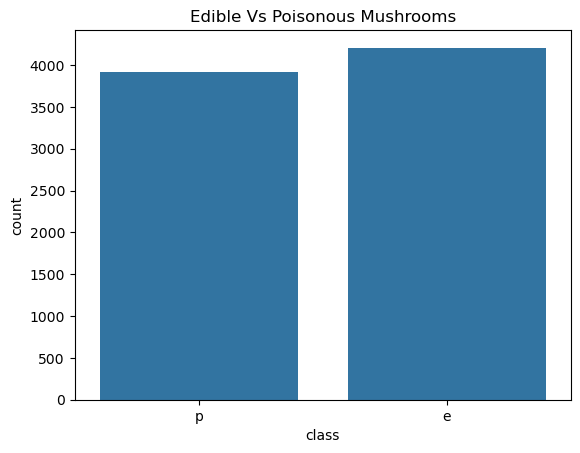

In [6]:
# check class distribution

print(data['class'].value_counts())
sns.countplot(x='class', data=data)
plt.title('Edible Vs Poisonous Mushrooms')
plt.show()

## Preprocess the Data

In [8]:
print(data['stalk-root'].value_counts())

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


In [9]:
# replacing '?' into 'unknown'

data['stalk-root'] = data['stalk-root'].replace('?', 'unknown')

## Encode Categorical Variables

In [10]:
# One-Hot Encoding
data_onehot = pd.get_dummies(data.drop('class', axis=1))
X_onehot = data_onehot
y = data['class'].map({'e': 0, 'p': 1}) #Encode target

In [12]:
from sklearn.model_selection import train_test_split

# split target
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, random_state=42) 

In [13]:
# train logistic regression

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_oh, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Evaluating the Model

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = lr_model.predict(X_test_oh)
print(f'Logisitc Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}')
print(classification_report(y_test, y_pred_lr, target_names=['Edible', 'Poisonous']))

Logisitc Regression Accuracy: 1.00
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       843
   Poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

